# Amenities Cleaning

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [6]:
districts_df = pd.read_csv("../data/districts.csv")
districts_df['id'] = range(1, 366)
districts_df.head(5)

,id,name_en,name_ar,slug,lat,lon,parent_id,gov_en,gov_ar
0,1,10 Ramadan 1,قسم اول مدينة العاشر من رمضان,10-ramadan-1-eg1309,30.222,31.732,EG13,Sharkia,الشرقية
1,2,10 Ramadan 2,قسم ثان مدينه العاشر من رمضان,10-ramadan-2-eg1321,30.238,31.700,EG13,Sharkia,الشرقية
2,3,15 Mayu,قسم 15 مايو,15-mayu-eg0103,29.853,31.387,EG01,Cairo,القاهرة
3,4,6 October-1,قسم أول 6 أكتوبر,6-october-1-eg2107,29.985,30.963,EG21,Giza,الجيزة
4,5,6 October-2,قسم ثان 6 أكتوبر,6-october-2-eg2121,29.941,30.908,EG21,Giza,الجيزة


In [2]:
amenities_df = pd.read_csv("../data/amenities.csv")
amenities_df.head(5)

,id,school_count,hospital_count,supermarket_count,park_count,metro_station_count,cafe_restaurant_count
0,44,0,0,0,0,0,0
1,45,0,0,0,0,0,0
2,46,1,0,0,0,0,0
3,47,48,83,56,6,1,200
4,48,2,0,0,0,0,0


In [5]:
amenities_df.describe()

,id,school_count,hospital_count,supermarket_count,park_count,metro_station_count,cafe_restaurant_count
count,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000
mean,183.000000,11.257534,25.775342,10.649315,0.821918,0.432877,43.345205
std,105.510663,22.767928,54.524961,22.202311,2.047127,1.226544,98.390181
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,92.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,183.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,274.000000,10.000000,21.000000,8.000000,0.000000,0.000000,31.000000
max,365.000000,120.000000,306.000000,110.000000,13.000000,9.000000,565.000000


In [60]:
amenities_merged_df = pd.merge(left=districts_df, right=amenities_df, on="id", how="left")
amenities_merged_df.head(1)

,id,name_en,name_ar,slug,lat,lon,parent_id,gov_en,gov_ar,school_count,hospital_count,supermarket_count,park_count,metro_station_count,cafe_restaurant_count
0,1,10 Ramadan 1,قسم اول مدينة العاشر من رمضان,10-ramadan-1-eg1309,30.222,31.732,EG13,Sharkia,الشرقية,0,0,0,0,0,1


In [61]:
amenities_merged_df = amenities_merged_df[['name_en', 'gov_en', 'school_count', 'hospital_count', 'supermarket_count', 'park_count', 'metro_station_count', 'cafe_restaurant_count']]

In [62]:
amenities_merged_df.describe()

,school_count,hospital_count,supermarket_count,park_count,metro_station_count,cafe_restaurant_count
count,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000
mean,11.257534,25.775342,10.649315,0.821918,0.432877,43.345205
std,22.767928,54.524961,22.202311,2.047127,1.226544,98.390181
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,10.000000,21.000000,8.000000,0.000000,0.000000,31.000000
max,120.000000,306.000000,110.000000,13.000000,9.000000,565.000000


In [63]:
amenities_merged_df.isnull().sum()

name_en                  0
gov_en                   0
school_count             0
hospital_count           0
supermarket_count        0
park_count               0
metro_station_count      0
cafe_restaurant_count    0
dtype: int64

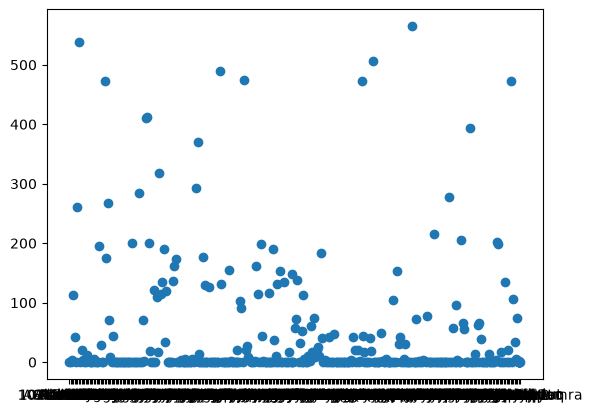

In [64]:
plt.scatter(amenities_merged_df['name_en'], amenities_merged_df['cafe_restaurant_count'])

In [54]:
def remove_outliers(df: pd.DataFrame, index: str):

    Q1 = df[index].quantile(0.25)
    Q3 = df[index].quantile(0.75)

    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df[index] = np.clip(df[index], lower_bound, upper_bound)
    return df

In [56]:
cleaned_amenties = amenities_merged_df.copy()

for col in ["school_count", "hospital_count", "supermarket_count", "park_count", "metro_station_count", "cafe_restaurant_count"]:
    cleaned_amenties = remove_outliers(cleaned_amenties, col)

In [58]:
cleaned_amenties.to_csv('../data/cleaned_amenties.csv')

In [65]:
amenities_merged_df.to_csv('../data/amenities_merged.csv.csv')

In [67]:
cols = ['school_count','hospital_count','supermarket_count','park_count',
        'metro_station_count','cafe_restaurant_count']
amenities_merged_df['_total'] = amenities_merged_df[cols].sum(axis=1)
amenities_merged_df = amenities_merged_df.sort_values('_total', ascending=False).drop_duplicates(subset=['name_en','gov_en'], keep='first')
amenities_merged_df = amenities_merged_df.drop(columns='_total').reset_index(drop=True)

---

# Property Value Data Cleaning

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
ApartmentsPrice_df = pd.read_csv('../data/Apartments Prices Dataset version 2 .csv')
ApartmentsPrice_df

,Price,Area,Rooms,Bathrooms,Floor Level,Year Built,Seller Type,View,Payment Method,Location,Amenities,Price_Numeric,Calculated_Price_Per_Meter
0,"2,163,000 EGP",120.0,2.0,3 bathroom,3.0,2025.0,Developer,Main Street,Installments,Second Neighborhood,Basic,2163000.0,18025.00
1,"3,250,000 EGP",162.0,3.0,2 bathroom,6.0,2024.0,Developer,Main Street,Cash or Installments,Jasmine Gardens Compound,Garden,3250000.0,20061.73
2,"2,650,000 EGP",122.0,3.0,1 bathroom,4.0,2024.0,Developer,Main Street,Cash or Installments,Sudan St,Finished,2650000.0,21721.31
3,"12,720,000 EGP",212.0,4.0,3 bathroom,13.0,2027.0,Broker,Club,Cash or Installments,Muruj,Super Lux,12720000.0,60000.00
4,"5,898,000 EGP",135.0,2.0,1 bathroom,6.0,2025.0,Developer,Lake,Cash or Installments,Unknown,Installment,5898000.0,43688.89
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4779,"8,500,000 EGP",183.0,3.0,NaN,NaN,NaN,NaN,Other,Cash,Palm Hills New,Basic,8500000.0,46448.09
4780,"2,800,000 EGP",180.0,3.0,2 bathroom,3.0,2019.0,Broker,Side Street,Cash,المنطقة و,Basic,2800000.0,15555.56
4781,"6,000,000 EGP",215.0,3.0,2 bathroom,7.0,2025.0,Broker,Other,Cash,Zahraa El Maadi,Basic,6000000.0,27906.98
4782,"7,500,000 EGP",400.0,4.0,3 bathroom,11.0,2009.0,Broker,Main Street,Cash,شارع مكرم عبيد,Basic,7500000.0,18750.00


In [18]:
def fix_bathrooms(row):
    try:
        return int(row.split()[0])
    except:
        return np.nan

ApartmentsPrice_df['Bathrooms'].apply(lambda x: fix_bathrooms(x))

0       3.0
1       2.0
2       1.0
3       3.0
4       1.0
       ... 
4779    NaN
4780    2.0
4781    2.0
4782    3.0
4783    2.0
Name: Bathrooms, Length: 4784, dtype: float64

In [19]:
ApartmentsPrice_df['Bathrooms'] = ApartmentsPrice_df['Bathrooms'].apply(lambda x: fix_bathrooms(x))

In [20]:
ApartmentsPrice_df['Bathrooms'].unique()

array([ 3.,  2.,  1.,  4., nan,  5., 22.,  6., 23.,  9., 11.])

In [21]:
ApartmentsPrice_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4784 entries, 0 to 4783
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Price                       4784 non-null   str    
 1   Area                        4784 non-null   float64
 2   Rooms                       4784 non-null   float64
 3   Bathrooms                   4763 non-null   float64
 4   Floor Level                 4451 non-null   float64
 5   Year Built                  4604 non-null   float64
 6   Seller Type                 4768 non-null   str    
 7   View                        4743 non-null   str    
 8   Payment Method              4757 non-null   str    
 9   Location                    4784 non-null   str    
 10  Amenities                   4769 non-null   str    
 11  Price_Numeric               4784 non-null   float64
 12  Calculated_Price_Per_Meter  4784 non-null   float64
dtypes: float64(7), str(6)
memory usage: 763.5 KB

In [22]:
ApartmentsPrice_df['Payment Method'].unique()

<ArrowStringArray>
['Installments', 'Cash or Installments', 'Cash', nan]
Length: 4, dtype: str